In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar

# =========================
# Load data
# =========================
#df = pd.read_csv(
#    r'C:\Users\mateo\ncaaBaseballDraft-Predictor\CSV+Code Files\pythagorean_expectation\ncaabb_teamStats.csv'
#)
df = pd.read_csv(
    'ncaabb_teamStats.csv'
)

# New cell: filter dataframe to years 2021-2025
if 'Year' in df.columns:
    df = df[df['Year'].between(2021, 2025)].copy()
elif 'year' in df.columns:
    df = df[df['year'].between(2021, 2025)].copy()
else:
    # fallback: find any column named like 'year' (case-insensitive)
    for col in df.columns:
        if col.lower() == 'year':
            df = df[df[col].between(2021, 2025)].copy()
            break

df = df.rename(columns={
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

df = df[
    (df['R'] > 0) &
    (df['RA'] > 0) &
    (~df['WPCT'].isna()) &
    (df['G'] >= 20)
].copy()

# =========================
# Pythagorean model
# =========================
def pythag_wpct(R, RA, gamma):
    return (R ** gamma) / (R ** gamma + RA ** gamma)

def r2_gamma(gamma, R, RA, WPCT):
    y_hat = pythag_wpct(R, RA, gamma)
    ss_res = np.sum((WPCT - y_hat) ** 2)
    ss_tot = np.sum((WPCT - WPCT.mean()) ** 2)
    return 1 - ss_res / ss_tot

# =========================
# Optimal gamma (ALL TEAMS)
# =========================
opt_all = minimize_scalar(
    lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']),
    bounds=(0.5, 4),
    method='bounded'
)

gamma_hat = opt_all.x
r2_opt = r2_gamma(gamma_hat, df['R'], df['RA'], df['WPCT'])

r2_183 = r2_gamma(1.83, df['R'], df['RA'], df['WPCT'])
r2_200 = r2_gamma(2.00, df['R'], df['RA'], df['WPCT'])

print("=== ALL TEAMS ===")
print(f"Optimal gamma: {gamma_hat:.4f}")
print(f"R^2 (optimal): {r2_opt:.6f}")
print(f"R^2 (1.83):    {r2_183:.6f}")
print(f"R^2 (2.00):    {r2_200:.6f}")

# =========================
# R^2-based confidence bounds
# =========================
# Rule: exponents within 0.001 of max R^2 are practically indistinguishable
# (standard sabermetric convention)

r2_tol = 0.001
gamma_grid = np.arange(1.2, 2.5, 0.001)

r2_grid = np.array([
    r2_gamma(g, df['R'], df['RA'], df['WPCT'])
    for g in gamma_grid
])

ci_lower = gamma_grid[r2_grid >= r2_opt - r2_tol].min()
ci_upper = gamma_grid[r2_grid >= r2_opt - r2_tol].max()

print(f"R^2-equivalent gamma range: [{ci_lower:.3f}, {ci_upper:.3f}]")

# =========================
# Conference-level results
# =========================
conference_results = []

for league, gdf in df.groupby('league'):
    if len(gdf) < 50:
        continue

    opt = minimize_scalar(
        lambda g: -r2_gamma(g, gdf['R'], gdf['RA'], gdf['WPCT']),
        bounds=(0.5, 4),
        method='bounded'
    )

    gamma_hat_c = opt.x
    r2_opt_c = r2_gamma(gamma_hat_c, gdf['R'], gdf['RA'], gdf['WPCT'])

    r2_grid_c = np.array([
        r2_gamma(g, gdf['R'], gdf['RA'], gdf['WPCT'])
        for g in gamma_grid
    ])

    ci_l = gamma_grid[r2_grid_c >= r2_opt_c - r2_tol].min()
    ci_u = gamma_grid[r2_grid_c >= r2_opt_c - r2_tol].max()

    conference_results.append({
        'league': league,
        'gamma_hat': gamma_hat_c,
        'r2': r2_opt_c,
        'ci_lower': ci_l,
        'ci_upper': ci_u,
        'n_obs': len(gdf)
    })

conference_df = pd.DataFrame(conference_results).sort_values('gamma_hat')

print("\n=== CONFERENCE RESULTS ===")
conference_df


=== ALL TEAMS ===
Optimal gamma: 1.7881
R^2 (optimal): 0.893011
R^2 (1.83):    0.892641
R^2 (2.00):    0.883854
R^2-equivalent gamma range: [1.720, 1.857]

=== CONFERENCE RESULTS ===


,league,gamma_hat,r2,ci_lower,ci_upper,n_obs
2,Big 12,1.572912,0.786589,1.529,1.617,54
11,Southland,1.593890,0.855972,1.536,1.652,50
3,Big Ten,1.630326,0.858476,1.571,1.690,69
0,ACC,1.677911,0.836894,1.634,1.723,72
5,CAA,1.692267,0.912444,1.631,1.754,53
9,SEC,1.704373,0.837404,1.662,1.747,72
10,SWAC,1.744189,0.893712,1.679,1.811,58
7,MAAC,1.819993,0.890166,1.750,1.891,56
12,Sun Belt,1.843810,0.881349,1.777,1.911,66
6,CUSA,1.848343,0.894588,1.781,1.917,53


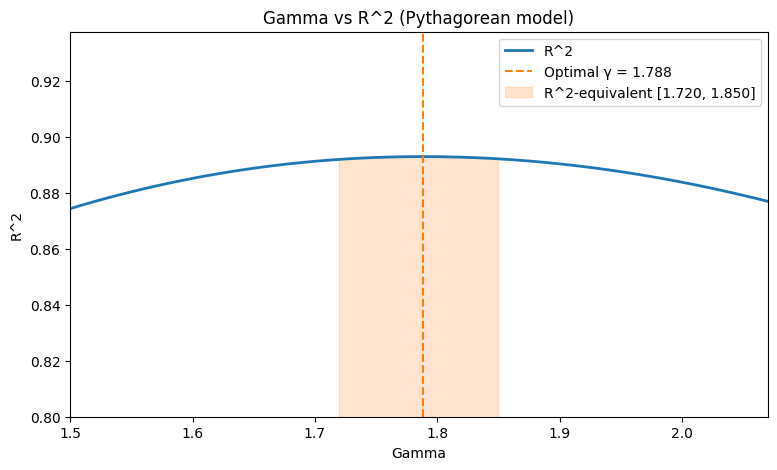

In [15]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# recompute grid & R^2 (safe if variables not in scope)
gamma_grid = np.arange(1.4, 2.5, 0.01)
r2_grid = np.array([r2_gamma(g, df['R'], df['RA'], df['WPCT']) for g in gamma_grid])

opt = minimize_scalar(lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']), bounds=(0.5, 4), method='bounded')
gamma_hat = opt.x
r2_opt = r2_gamma(gamma_hat, df['R'], df['RA'], df['WPCT'])
r2_tol = 0.001
ci_lower = gamma_grid[r2_grid >= r2_opt - r2_tol].min()
ci_upper = gamma_grid[r2_grid >= r2_opt - r2_tol].max()

plt.figure(figsize=(9,5))
plt.plot(gamma_grid, r2_grid, lw=2, label='R^2')
plt.axvline(gamma_hat, color='C1', ls='--', label=f'Optimal γ = {gamma_hat:.3f}')
plt.fill_between(gamma_grid, r2_grid, where=(gamma_grid >= ci_lower) & (gamma_grid <= ci_upper), color='C1', alpha=0.2, label=f'R^2-equivalent [{ci_lower:.3f}, {ci_upper:.3f}]')
plt.xlabel('Gamma')
plt.xlim(1.5, 2.07)
plt.ylabel('R^2')
plt.ylim(bottom=0.8)
plt.title('Gamma vs R^2 (Pythagorean model)')
plt.legend()
plt.show()

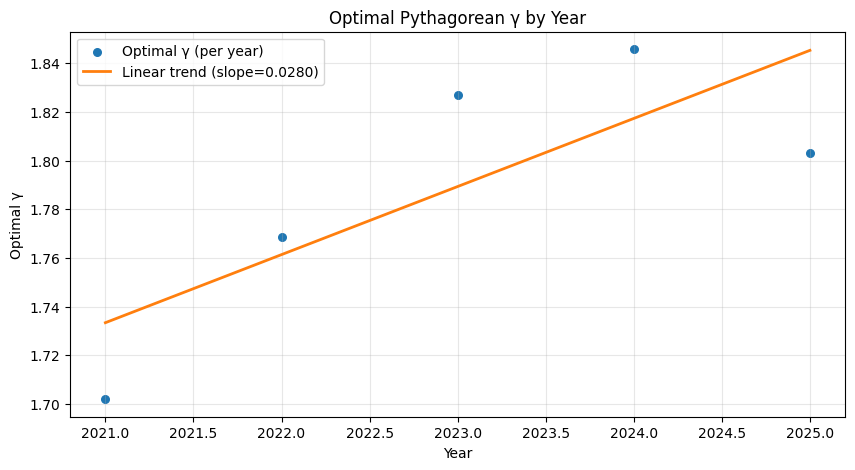

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# compute optimal gamma per year (require >=10 teams per year)
year_results = []
for year, ydf in df.groupby('year'):
    if len(ydf) < 10:
        continue
    opt = minimize_scalar(
        lambda g: -r2_gamma(g, ydf['R'], ydf['RA'], ydf['WPCT']),
        bounds=(0.5, 4), method='bounded'
    )
    year_results.append({'year': int(year), 'gamma': opt.x, 'n': len(ydf)})

year_df = pd.DataFrame(year_results).sort_values('year')

# linear trend
z = np.polyfit(year_df['year'], year_df['gamma'], 1)
p = np.poly1d(z)

plt.figure(figsize=(10,5))
plt.scatter(year_df['year'], year_df['gamma'], s=30, c='C0', label='Optimal γ (per year)')
plt.plot(year_df['year'], p(year_df['year']), color='C1', lw=2, label=f'Linear trend (slope={z[0]:.4f})')
plt.xlabel('Year')
plt.ylabel('Optimal γ')
plt.title('Optimal Pythagorean γ by Year')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar

# =========================
# Load data
# =========================
#df = pd.read_csv(
#    r'C:\Users\mateo\ncaaBaseballDraft-Predictor\CSV+Code Files\pythagorean_expectation\ncaabb_teamStats.csv'
#)
df = pd.read_csv(
    'ncaabb_teamStats.csv'
)

# New cell: filter dataframe to years 2021-2025
if 'Year' in df.columns:
    df = df[df['Year'].between(2021, 2025)].copy()
elif 'year' in df.columns:
    df = df[df['year'].between(2021, 2025)].copy()
else:
    # fallback: find any column named like 'year' (case-insensitive)
    for col in df.columns:
        if col.lower() == 'year':
            df = df[df[col].between(2021, 2025)].copy()
            break

df = df.rename(columns={
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

df = df[
    (df['R'] > 0) &
    (df['RA'] > 0) &
    (~df['WPCT'].isna()) &
    (df['G'] >= 20)
].copy()

# =========================
# Pythagorean model
# =========================
def pythag_wpct(R, RA, gamma):
    return (R ** gamma) / (R ** gamma + RA ** gamma)

def r2_gamma(gamma, R, RA, WPCT):
    y_hat = pythag_wpct(R, RA, gamma)
    ss_res = np.sum((WPCT - y_hat) ** 2)
    ss_tot = np.sum((WPCT - WPCT.mean()) ** 2)
    return 1 - ss_res / ss_tot

# =========================
# Global optimal gamma
# =========================
opt_all = minimize_scalar(
    lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']),
    bounds=(0.5, 4),
    method='bounded'
)

gamma_hat_global = opt_all.x
r2_global = r2_gamma(gamma_hat_global, df['R'], df['RA'], df['WPCT'])

# =========================
# Conference-level gammas
# =========================
league_gamma = {}

for league, gdf in df.groupby('league'):
    if len(gdf) < 50:
        continue

    opt = minimize_scalar(
        lambda g: -r2_gamma(g, gdf['R'], gdf['RA'], gdf['WPCT']),
        bounds=(0.5, 4),
        method='bounded'
    )

    league_gamma[league] = opt.x

# =========================
# Example team (reproducible)
# =========================
found_seed = None
max_seed = 20000
target = "northeastern"

for s in range(max_seed):
    np.random.seed(s)
    example_idx = np.random.choice(df.index)
    row = df.loc[example_idx]
    name = str(row.get('team', '')).lower()
    if target in name:
        found_seed = s
        team_row = row
        print(f"Found Northeastern with seed {s}")
        break

if found_seed is None:
    # fallback: use first direct match in dataset if any
    matches = df[df['team'].str.lower().str.contains(target, na=False)]
    if len(matches) > 0:
        team_row = matches.iloc[0]
        print("Northeastern not found via random seeds; using first direct match from dataset")
    else:
        raise ValueError("Northeastern not found in dataset")

team_R = team_row['R']
team_RA = team_row['RA']
team_WPCT = team_row['WPCT']
team_league = team_row['league']
team_name = team_row['team']
team_year = team_row['year']
team_G = int(team_row['G'])
team_W = int(team_row['W'])
team_L = int(team_row['L'])

# =========================
# Predicted WPCTs
# =========================
wpct_pred = {
    'Global optimal γ': pythag_wpct(team_R, team_RA, gamma_hat_global),
    'League γ': pythag_wpct(team_R, team_RA, league_gamma.get(team_league, gamma_hat_global)),
    'γ = 1.83': pythag_wpct(team_R, team_RA, 1.83),
    'γ = 2.00': pythag_wpct(team_R, team_RA, 2.00)
}

# =========================
# Convert WPCT → W–L
# =========================
wl_pred = {}

for model, wp in wpct_pred.items():
    wins = wp * team_G
    losses = team_G - wins
    wl_pred[model] = f"{wins:.1f}–{losses:.1f}"

# =========================
# R^2 comparison (full data)
# =========================
r2_comparison = {
    'Global optimal γ': r2_gamma(gamma_hat_global, df['R'], df['RA'], df['WPCT']),
    'League γ': r2_gamma(
        league_gamma.get(team_league, gamma_hat_global),
        df['R'], df['RA'], df['WPCT']
    ),
    'γ = 1.83': r2_gamma(1.83, df['R'], df['RA'], df['WPCT']),
    'γ = 2.00': r2_gamma(2.00, df['R'], df['RA'], df['WPCT'])
}

# =========================
# Output table
# =========================
pred_wins = [wp * team_G for wp in wpct_pred.values()]                    # numeric predicted wins
pred_wl_formatted = [f"{pw:.1f}–{(team_G - pw):.1f}" for pw in pred_wins]  # formatted W–L
win_diff = [pw - team_W for pw in pred_wins]                              # predicted - actual wins

example_df = pd.DataFrame({
    'Model': list(wpct_pred.keys()),
    'Predicted WPCT': list(wpct_pred.values()),
    'Predicted W–L': pred_wl_formatted,
    'Predicted Wins': [round(pw, 1) for pw in pred_wins],
    'Win Diff (Pred - Actual)': [round(d, 1) for d in win_diff],
    'R^2 (full dataset)': list(r2_comparison.values())
})

print("=== EXAMPLE TEAM ===")
print(f"Team: {team_name} ({team_year})")
print(f"League: {team_league}")
print(f"Games Played: {team_G}")
print(f"Actual Record: {team_W}–{team_L}")
print(f"Runs Scored: {team_R:.0f}")
print(f"Runs Allowed: {team_RA:.0f}")
print(f"Actual WPCT: {team_WPCT:.3f}")
print(f"League γ: {league_gamma.get(team_league, gamma_hat_global):.3f}")
print(f"Global γ: {gamma_hat_global:.3f}")

example_df

Found Northeastern with seed 241
=== EXAMPLE TEAM ===
Team: Northeastern (2022)
League: CAA
Games Played: 61
Actual Record: 31–29
Runs Scored: 300
Runs Allowed: 259
Actual WPCT: 0.508
League γ: 1.692
Global γ: 1.788


,Model,Predicted WPCT,Predicted W–L,Predicted Wins,Win Diff (Pred - Actual),R^2 (full dataset)
0,Global optimal γ,0.565318,34.5–26.5,34.5,3.5,0.893011
1,League γ,0.561853,34.3–26.7,34.3,3.3,0.891023
2,γ = 1.83,0.566829,34.6–26.4,34.6,3.6,0.892641
3,γ = 2.00,0.572953,35.0–26.0,35.0,4.0,0.883854


          count      mean       std    median       min       max
model                                                            
Global γ   1466  0.233788  2.441864  0.210579 -9.105276  8.589081
League γ   1466  0.167675  2.427403  0.169860 -9.105276  7.901977
γ = 1.83   1466  0.246102  2.445401  0.225033 -9.049434  8.802833
γ = 2.00   1466  0.296018  2.544342  0.278492 -8.822907  9.655621


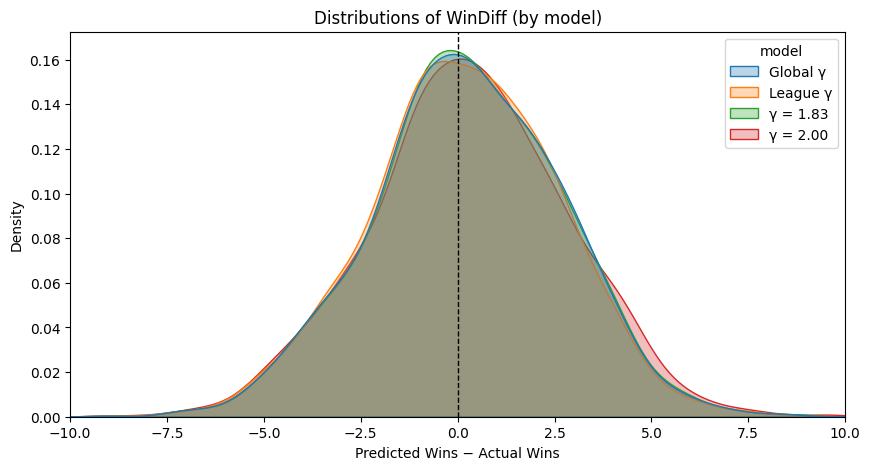

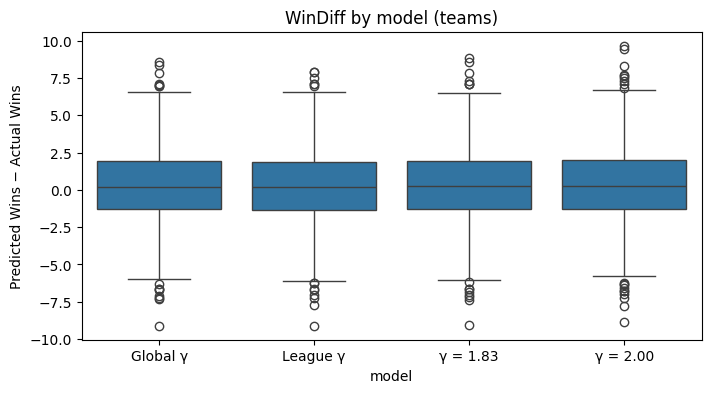

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# prepare per-team league gamma (fallback to global if league missing)
df['gamma_league'] = df['league'].map(league_gamma).fillna(gamma_hat_global)

# compute WinDiff for four gammas of interest
rows = []
# Global optimal
wp_global = pythag_wpct(df['R'], df['RA'], gamma_hat_global)
rows.append(pd.DataFrame({'model': 'Global γ', 'win_diff': (wp_global * df['G'] - df['W']).values}))
# League (per-team) gamma
wp_league = pythag_wpct(df['R'], df['RA'], df['gamma_league'])
rows.append(pd.DataFrame({'model': 'League γ', 'win_diff': (wp_league * df['G'] - df['W']).values}))
# γ = 1.83
wp_183 = pythag_wpct(df['R'], df['RA'], 1.83)
rows.append(pd.DataFrame({'model': 'γ = 1.83', 'win_diff': (wp_183 * df['G'] - df['W']).values}))
# γ = 2.00
wp_200 = pythag_wpct(df['R'], df['RA'], 2.00)
rows.append(pd.DataFrame({'model': 'γ = 2.00', 'win_diff': (wp_200 * df['G'] - df['W']).values}))

win_diff_df = pd.concat(rows, ignore_index=True)

# summary statistics
print(win_diff_df.groupby('model')['win_diff'].agg(['count','mean','std','median','min','max']))

# density plot (overlaid)
plt.figure(figsize=(10,5))
sns.kdeplot(data=win_diff_df, x='win_diff', hue='model', fill=True, alpha=0.3, common_norm=False)
plt.axvline(0, color='k', ls='--', lw=1)
plt.xlabel('Predicted Wins − Actual Wins')
plt.xlim(-10, 10)
plt.title('Distributions of WinDiff (by model)')
plt.show()

# boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data=win_diff_df, x='model', y='win_diff')
plt.ylabel('Predicted Wins − Actual Wins')
plt.title('WinDiff by model (teams)')
plt.show()

R^2 mean: 0.863281, std: 0.026609
95% z-cutoff (r2_tol): 0.052154
R^2-equivalent gamma 95% CI: [1.314, 2.309] (optimal 1.788)


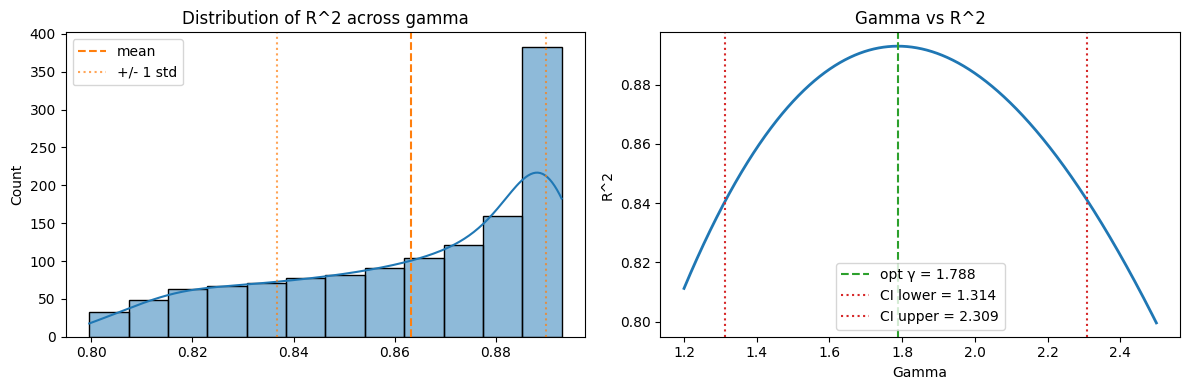

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar

# recompute grid & R^2
gamma_grid = np.arange(1.2, 2.5, 0.001)
r2_grid = np.array([r2_gamma(g, df['R'], df['RA'], df['WPCT']) for g in gamma_grid])

mean_r2 = float(np.mean(r2_grid))
std_r2 = float(np.std(r2_grid, ddof=0))
print(f"R^2 mean: {mean_r2:.6f}, std: {std_r2:.6f}")

# find global optimum
opt = minimize_scalar(lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']), bounds=(0.5,4), method='bounded')
gamma_hat = opt.x
r2_opt = r2_gamma(gamma_hat, df['R'], df['RA'], df['WPCT'])

# 95% z-cutoff using empirical std
r2_tol = 1.96 * std_r2
mask = r2_grid >= (r2_opt - r2_tol)
ci_lower = float(gamma_grid[mask].min())
ci_upper = float(gamma_grid[mask].max())

print(f"95% z-cutoff (r2_tol): {r2_tol:.6f}")
print(f"R^2-equivalent gamma 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}] (optimal {gamma_hat:.3f})")

# plots: distribution of R^2 and gamma vs R^2 with CI
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(r2_grid, kde=True, ax=axes[0], color='C0')
axes[0].axvline(mean_r2, color='C1', ls='--', label='mean')
axes[0].axvline(mean_r2+std_r2, color='C1', ls=':', alpha=0.7, label='+/- 1 std')
axes[0].axvline(mean_r2-std_r2, color='C1', ls=':', alpha=0.7)
axes[0].set_title('Distribution of R^2 across gamma')
axes[0].legend()

axes[1].plot(gamma_grid, r2_grid, lw=2, color='C0')
axes[1].axvline(gamma_hat, color='C2', ls='--', label=f'opt γ = {gamma_hat:.3f}')
axes[1].axvline(ci_lower, color='C3', ls=':', label=f'CI lower = {ci_lower:.3f}')
axes[1].axvline(ci_upper, color='C3', ls=':', label=f'CI upper = {ci_upper:.3f}')
axes[1].set_xlabel('Gamma')
axes[1].set_ylabel('R^2')
axes[1].set_title('Gamma vs R^2')
axes[1].legend()

plt.tight_layout()
plt.show()